# 02 — Exploratory data analysis

The charts answer three business questions: how demand changed over time, how merchant penetration varies, and whether high growth appears where registered-merchant penetration is lower.

In [1]:
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
import pandas as pd
import seaborn as sns

ROOT = Path.cwd()
ANALYSIS = ROOT / "data" / "processed" / "analysis"
sns.set_theme(style="whitegrid")
national = pd.read_csv(ANALYSIS / "national_metrics.csv")
district = pd.read_csv(ANALYSIS / "district_metrics.csv")
opportunities = pd.read_csv(ANALYSIS / "district_opportunities.csv")

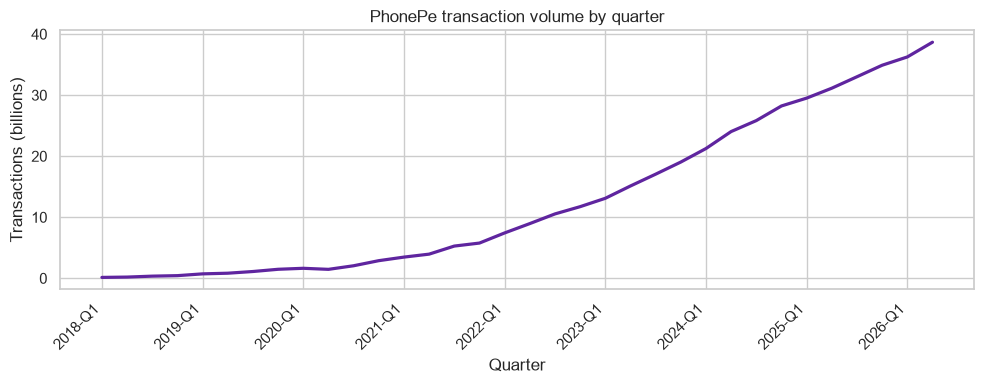

In [2]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(
    national["period_label"], national["transaction_count"] / 1e9, color="#5F259F", linewidth=2.3
)
ax.set(
    title="PhonePe transaction volume by quarter",
    xlabel="Quarter",
    ylabel="Transactions (billions)",
)
ax.set_xticks(
    range(0, len(national), 4), national["period_label"].iloc[::4], rotation=45, ha="right"
)
plt.tight_layout()
plt.show()

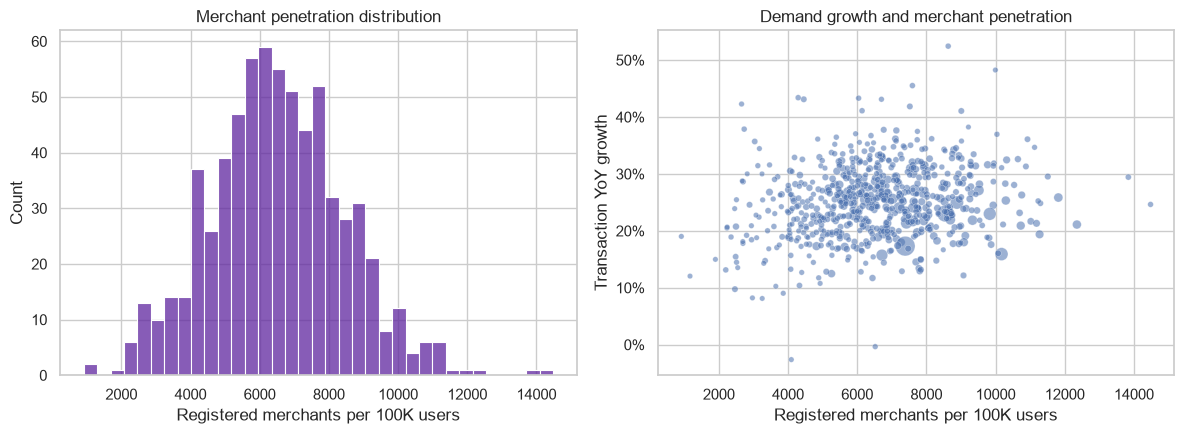

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(opportunities["merchants_per_100k_users"], bins=35, color="#5F259F", ax=axes[0])
axes[0].set(title="Merchant penetration distribution", xlabel="Registered merchants per 100K users")
sns.scatterplot(
    data=opportunities,
    x="merchants_per_100k_users",
    y="transaction_yoy",
    size="registered_users",
    sizes=(15, 200),
    alpha=0.55,
    legend=False,
    ax=axes[1],
)
axes[1].yaxis.set_major_formatter(PercentFormatter(1))
axes[1].set(
    title="Demand growth and merchant penetration",
    xlabel="Registered merchants per 100K users",
    ylabel="Transaction YoY growth",
)
plt.tight_layout()
plt.show()

The distributions are long-tailed, so raw values would let a few districts dominate a combined score. Percentile ranking is a reasonable, explainable normalization choice. The scatterplot is descriptive; it does not show that low merchant penetration causes growth.